   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


✅ Loaded fedavg from Part A
✅ Loaded weighted_fedavg from Part A
✅ Loaded fedprox from Part B
✅ Loaded ditto from Part B

Building centralized baseline (streaming)...
Centralized train: 18605 samples


Centralized → Acc=0.7365  F1=0.6541

Training local-only models (streaming)...


  C0 local → Acc=0.6397  F1=0.3741


  C1 local → Acc=0.6447  F1=0.3267


  C2 local → Acc=0.5806  F1=0.3804

Computing Grad-CAM IoU...
  fedavg: avg=0.4223  per-client=['0.502', '0.339', '0.426']
  weighted_fedavg: avg=0.3171  per-client=['0.333', '0.370', '0.248']
  fedprox: avg=0.5294  per-client=['0.580', '0.496', '0.511']
  ditto: avg=0.4969  per-client=['0.496', '0.506', '0.488']

===== FINAL TEST METRICS =====
Method                   Acc     F1      G-mean    BalAcc    IoU     
------------------------------------------------------------------------
Centralized              0.7365  0.6541  0.6362    0.6470    N/A
Best Local (C2)          0.5806  0.3804  0.0495    0.4694    N/A
fedavg                   0.7199  0.5486  0.4847    0.5164    0.4223
weighted_fedavg          0.6849  0.4263  0.2914    0.3956    0.3171
fedprox                  0.7079  0.5501  0.5038    0.5335    0.5294
ditto                    0.7246  0.5609  0.5008    0.5380    0.4969

✅ Best FL improvement over local: 47.5%


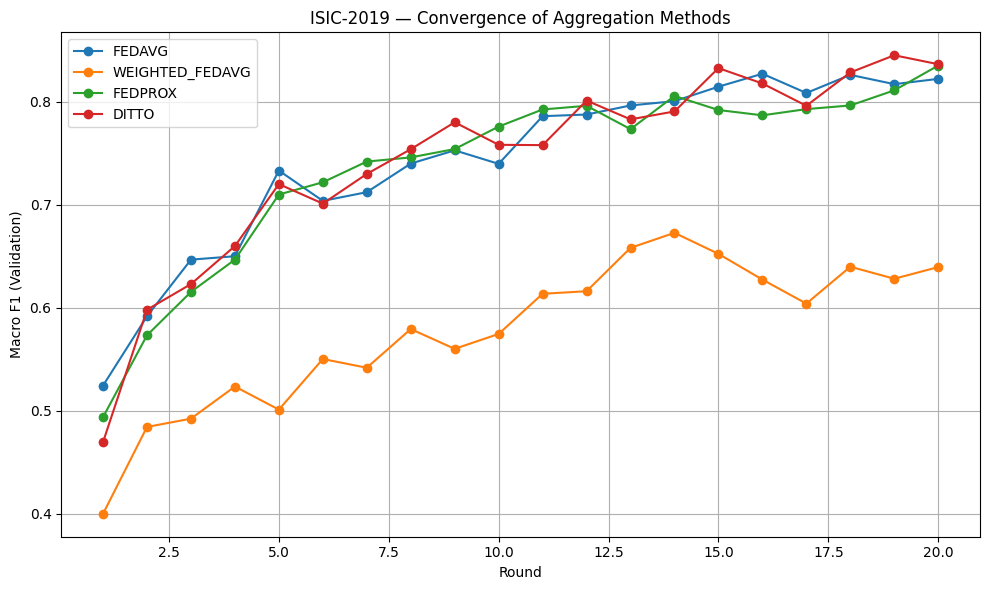

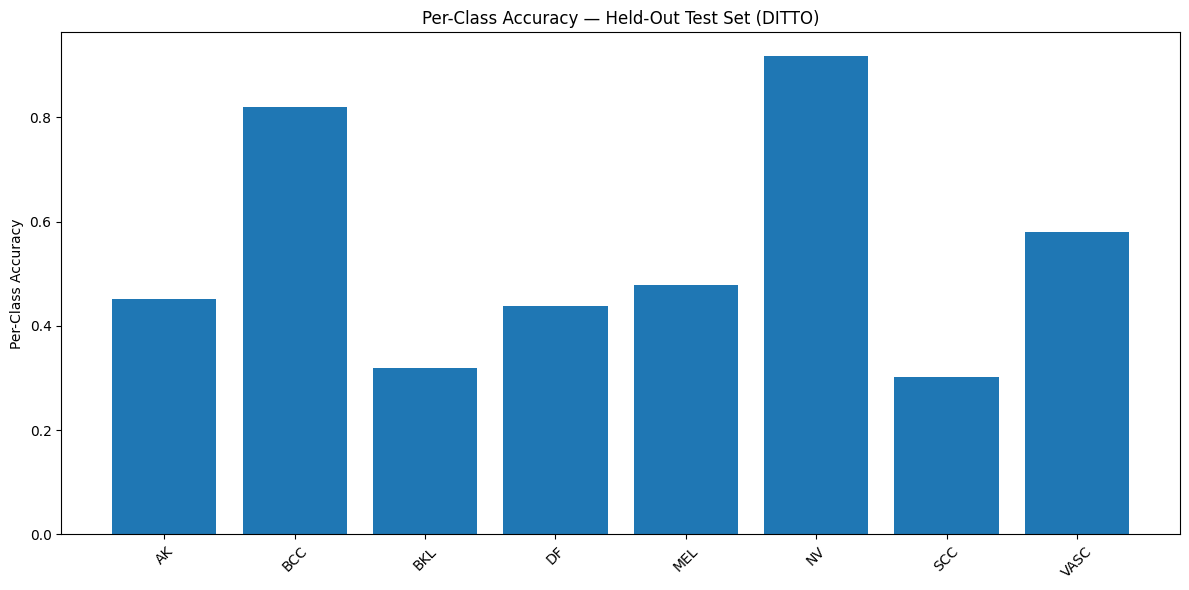

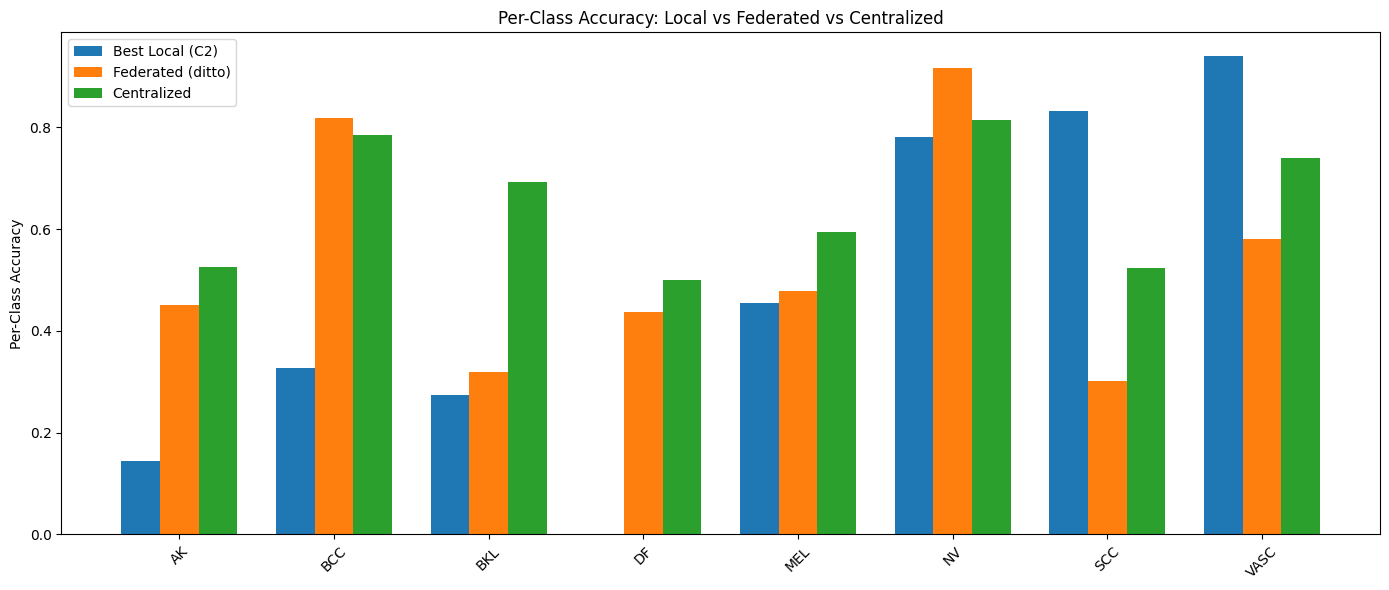

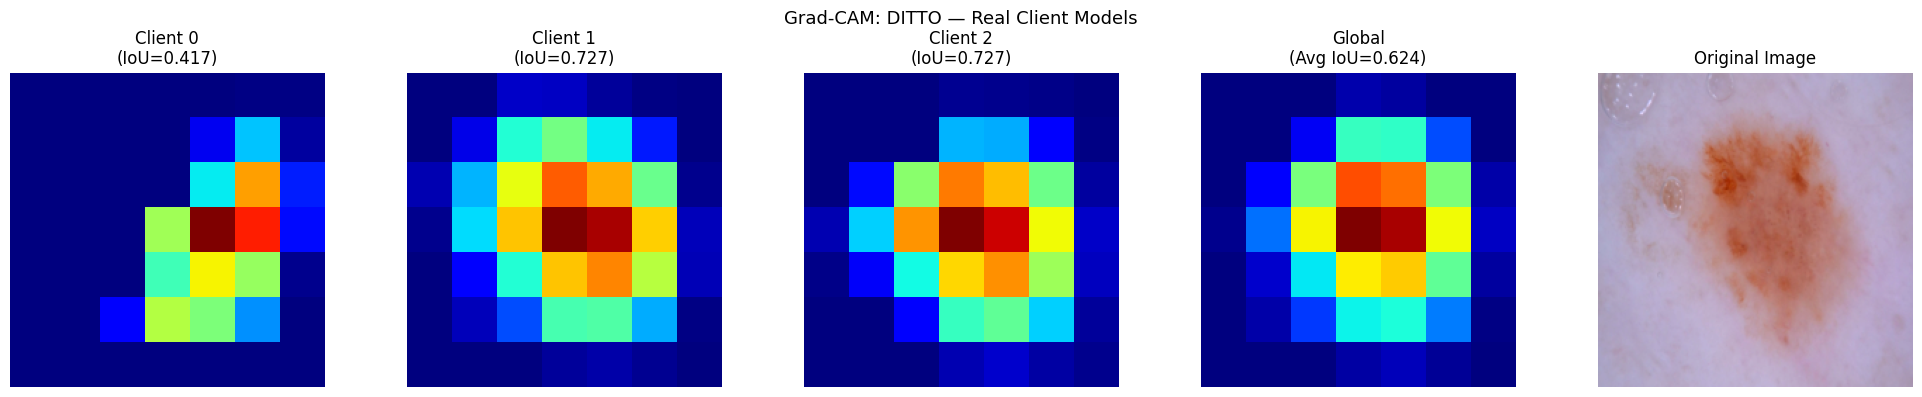

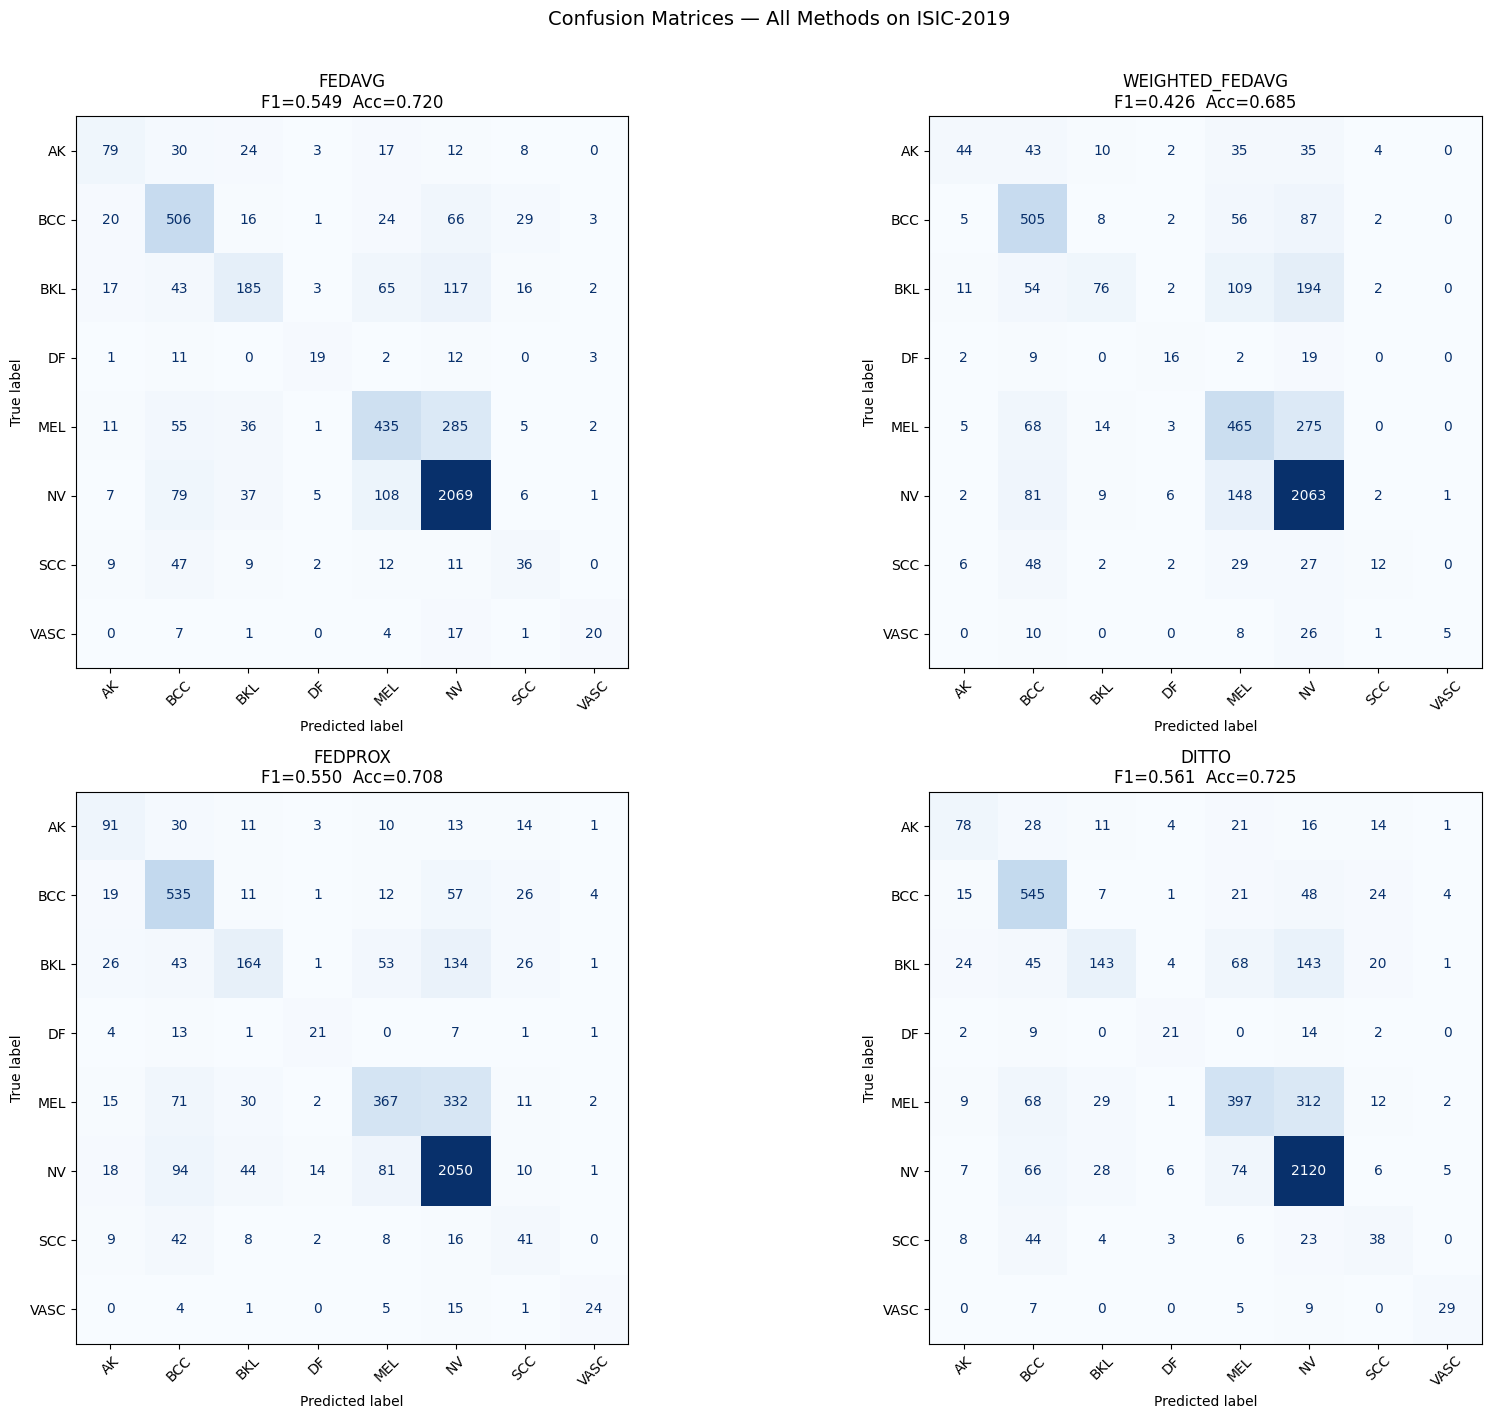

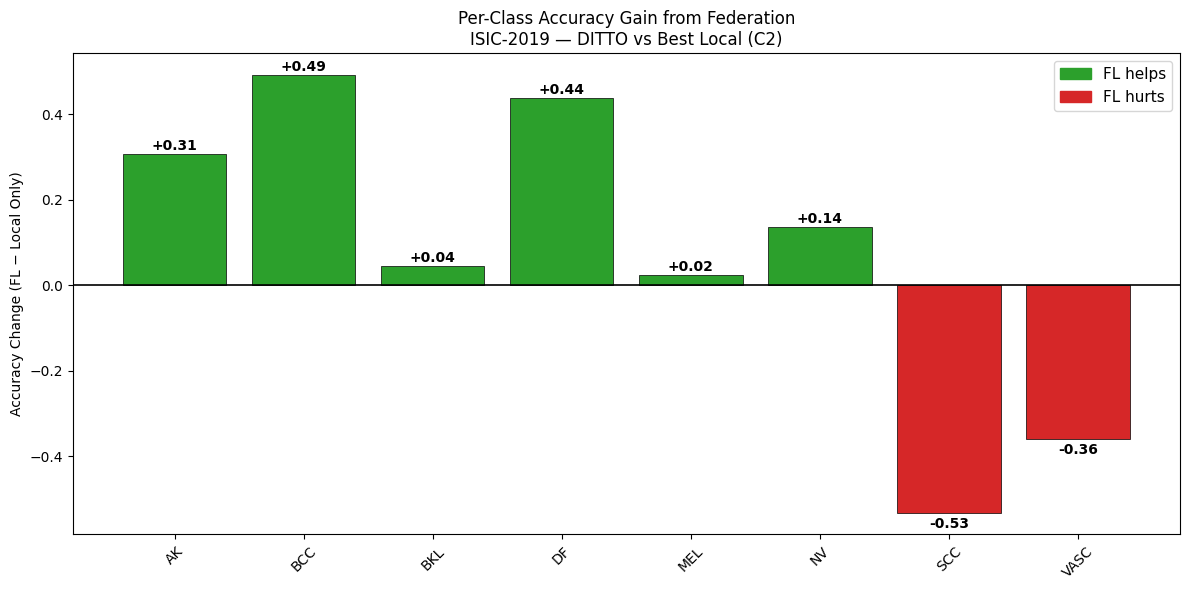

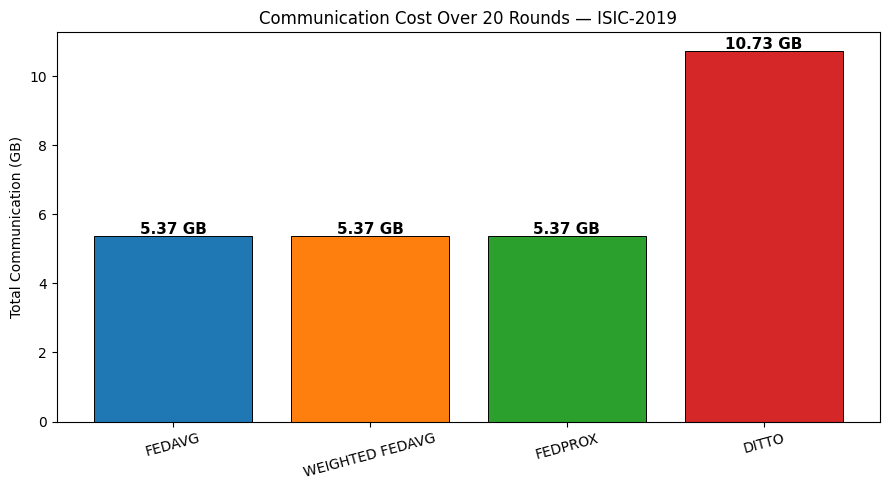

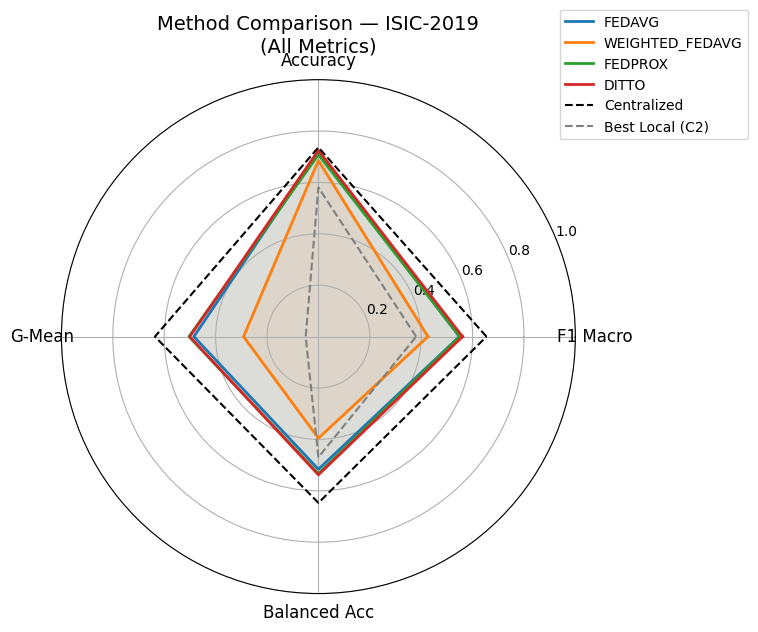

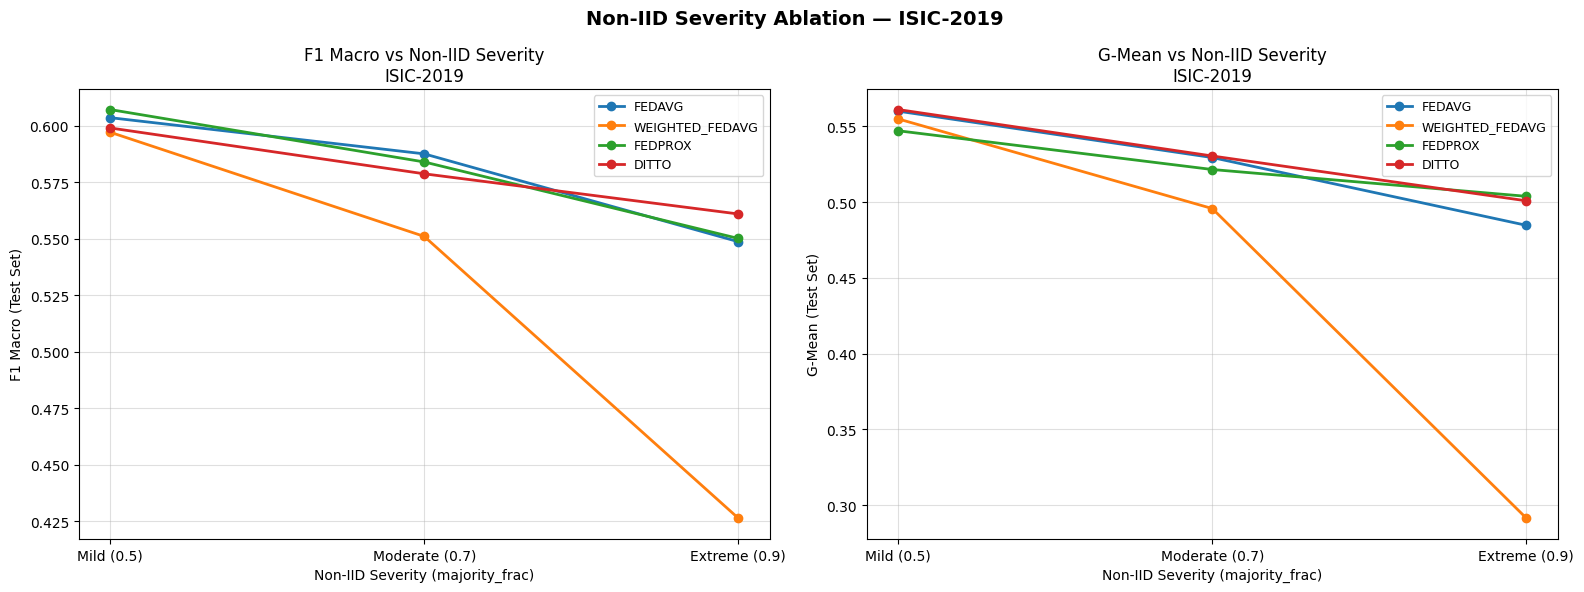


Ablation F1 Macro pivot:
majority_frac       0.5     0.7     0.9
method                                 
ditto            0.5989  0.5787  0.5609
fedavg           0.6035  0.5875  0.5486
fedprox          0.6071  0.5839  0.5501
weighted_fedavg  0.5971  0.5510  0.4263

✅ All validation complete.
Saved: final_comparison_table_corrected.csv, fl_results_all_methods.csv
       ablation_results.csv, ablation_pivot.csv, communication_cost.csv
       convergence_clean.png, per_class_accuracy.png
       per_class_comparison_corrected.png, gradcam_real_clients.png
       confusion_matrices_all.png, fl_gain_per_class.png
       communication_cost.png, radar_chart.png, ablation_severity.png


In [1]:
# ==========================================
# NOTEBOOK 2: ISIC-2019 COMBINED VALIDATION
# Requires both datasets as inputs:
#   isic-fl-part-a → /kaggle/input/isic-fl-part-a/
#   isic-fl-part-b → /kaggle/input/isic-fl-part-b/
# ==========================================

!pip install -q scikit-learn torchmetrics tqdm

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# PATHS — update if your dataset names differ
# ==========================================
PART_A_PATH = "/kaggle/input/datasets/setu295452/isic-fl-part-a"
PART_B_PATH = "/kaggle/input/datasets/setu295452/isic-fl-part-b"

# ==========================================
# 1. LOAD SHARED ASSETS FROM PART A
# ==========================================
with open(os.path.join(PART_A_PATH,"meta.json")) as f:
    meta = json.load(f)
class_to_idx                = meta['class_to_idx']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
num_classes                 = len(class_names)
print(f"Classes: {class_to_idx}")

DATA_DIR = "/kaggle/input/isic-2019-skin-lesion-images-for-classification"
if not os.path.exists(DATA_DIR):
    import kagglehub
    DATA_DIR = kagglehub.dataset_download(
        "salviohexia/isic-2019-skin-lesion-images-for-classification")

image_paths={}
for cn in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
    cd=os.path.join(DATA_DIR,cn)
    if not os.path.isdir(cd): continue
    for fname in os.listdir(cd):
        if fname.endswith('.jpg'):
            base=fname.replace('_downsampled.jpg','').replace('.jpg','')
            image_paths[base]=os.path.join(cd,fname)
print(f"Found {len(image_paths)} images.")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ==========================================
# 2. TEST SET (streaming)
# ==========================================
test_df = pd.read_csv(os.path.join(PART_A_PATH,"test_df.csv"))
test_df['label'] = test_df['label'].astype(int)
print(f"Test set: {len(test_df)} samples")

class StreamingDataset(Dataset):
    def __init__(self,df,image_paths,transform=None):
        self.df=df.reset_index(drop=True)
        self.image_paths=image_paths
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        try: img=Image.open(self.image_paths[row['image_base']]).convert("RGB")
        except: img=Image.new("RGB",(224,224))
        if self.transform: img=self.transform(img)
        return img,int(row['label'])

test_dataset = StreamingDataset(test_df,image_paths,transform)
test_loader  = DataLoader(test_dataset,batch_size=32,shuffle=False,
                          num_workers=4,pin_memory=True)

# ==========================================
# 3. HELPERS
# ==========================================
def get_model():
    m=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc=nn.Linear(m.fc.in_features,num_classes)
    return m.to(device)

def evaluate_model(model,dataloader):
    model.eval()
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for x,y in dataloader:
            x=x.to(device)
            preds=torch.argmax(F.softmax(model(x),dim=1),dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    y_true,y_pred=np.array(all_labels),np.array(all_preds)
    pc_acc,pc_rec=[],[]
    for c in range(num_classes):
        idx=y_true==c
        pc_acc.append(float(np.mean(y_pred[idx]==c)) if idx.sum()>0 else 0.0)
        tp=np.sum((y_pred==c)&(y_true==c))
        fn=np.sum((y_pred!=c)&(y_true==c))
        pc_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,average='macro',zero_division=0)),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'g_mean':             float(np.exp(np.mean(np.log([r+1e-8 for r in pc_rec])))),
        'per_class_accuracy': pc_acc,
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
    }

def grad_cam(model,img_tensor,target_class,target_layer='layer4'):
    model.eval()
    img_t=img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    grads,acts=[],[]
    def bwd(m,gi,go): grads.append(go[0])
    def fwd(m,i,o):   acts.append(o)
    tm=dict(model.named_modules()).get(target_layer)
    h1=tm.register_forward_hook(fwd); h2=tm.register_backward_hook(bwd)
    out=model(img_t); out[0,target_class].backward()
    h1.remove(); h2.remove()
    grad=grads[0].cpu().detach().numpy()[0]
    act=acts[0].cpu().detach().numpy()[0]
    weights=np.mean(grad,axis=(1,2))
    cam=np.maximum(np.sum([w*a for w,a in zip(weights,act)],axis=0),0)
    cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam

def compute_iou(m1,m2,threshold=0.5):
    b1=(m1>threshold).astype(np.uint8); b2=(m2>threshold).astype(np.uint8)
    inter=np.logical_and(b1,b2).sum(); union=np.logical_or(b1,b2).sum()
    return (inter/union) if union>0 else (1.0 if inter==0 else 0.0)

def compute_avg_iou(gm,cms,dataset,n_samples=50,threshold=0.5):
    np.random.seed(42)
    indices=np.random.choice(len(dataset),n_samples,replace=False)
    all_ious=[[] for _ in cms]
    for idx in indices:
        img,label=dataset[idx]
        g_cam=grad_cam(gm,img.to(device),label)
        for cid,cm in enumerate(cms):
            all_ious[cid].append(compute_iou(g_cam,grad_cam(cm,img.to(device),label),threshold))
    per=[float(np.mean(v)) for v in all_ious]
    return float(np.mean(per)),per

# ==========================================
# 4. LOAD ALL 4 FL MODELS
# ==========================================
method_names     = ['fedavg','weighted_fedavg','fedprox','ditto']
fl_models        = {}
fl_client_models = {}

# Part A models (fedavg, weighted_fedavg)
for name in ['fedavg','weighted_fedavg']:
    gm=get_model()
    gm.load_state_dict(torch.load(
        os.path.join(PART_A_PATH,f"final_model_{name}.pth"),
        map_location=device))
    fl_models[name]=gm
    clist=[]
    for cid in range(3):
        cm=get_model()
        cm.load_state_dict(torch.load(
            os.path.join(PART_A_PATH,f"client_{name}_{cid}.pth"),
            map_location=device))
        clist.append(cm)
    fl_client_models[name]=clist
    print(f"✅ Loaded {name} from Part A")

# Part B models (fedprox, ditto)
for name in ['fedprox','ditto']:
    gm=get_model()
    gm.load_state_dict(torch.load(
        os.path.join(PART_B_PATH,f"final_model_{name}.pth"),
        map_location=device))
    fl_models[name]=gm
    clist=[]
    for cid in range(3):
        cm=get_model()
        cm.load_state_dict(torch.load(
            os.path.join(PART_B_PATH,f"client_{name}_{cid}.pth"),
            map_location=device))
        clist.append(cm)
    fl_client_models[name]=clist
    print(f"✅ Loaded {name} from Part B")

# ==========================================
# 5. CENTRALIZED BASELINE
# ==========================================
print("\nBuilding centralized baseline (streaming)...")
csv_path=os.path.join(DATA_DIR,"ISIC_2019_Training_GroundTruth.csv")
full_df=pd.read_csv(csv_path)
lesion_cols=['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']
full_df['target']=full_df[lesion_cols].idxmax(axis=1)
full_df['label']=full_df['target'].map(class_to_idx)
full_df['image_base']=full_df['image']
full_df=full_df[full_df['image_base'].isin(image_paths.keys())]
full_df=full_df[full_df['label'].notna()].reset_index(drop=True)
full_df['label']=full_df['label'].astype(int)

train_df_c,_=train_test_split(
    full_df,test_size=0.2,stratify=full_df['label'],random_state=42)
train_df_c=train_df_c.reset_index(drop=True)
print(f"Centralized train: {len(train_df_c)} samples")

c_labels=train_df_c['label'].values
c_counts=np.bincount(c_labels,minlength=num_classes)
c_sw=1.0/c_counts[c_labels]; c_sw/=c_sw.sum()
c_sampler=WeightedRandomSampler(
    torch.tensor(c_sw,dtype=torch.float32),len(c_sw),replacement=True)
c_loader=DataLoader(
    StreamingDataset(train_df_c,image_paths,transform),
    batch_size=32,sampler=c_sampler,num_workers=4,pin_memory=True)

central_model=get_model()
c_opt=torch.optim.Adam(central_model.parameters(),lr=1e-4)
c_crit=nn.CrossEntropyLoss()

for epoch in range(3):
    central_model.train()
    for x,y in tqdm(c_loader,desc=f"Central epoch {epoch+1}",leave=False):
        x,y=x.to(device),y.to(device)
        c_opt.zero_grad(); c_crit(central_model(x),y).backward(); c_opt.step()

central_metrics=evaluate_model(central_model,test_loader)
print(f"Centralized → Acc={central_metrics['accuracy']:.4f}  "
      f"F1={central_metrics['f1_macro']:.4f}")
del c_loader; torch.cuda.empty_cache()

# ==========================================
# 6. LOCAL-ONLY BASELINES
# ==========================================
def disjoint_non_iid_split(labels,majority_classes_per_client,
                            majority_frac=0.9,seed=42):
    np.random.seed(seed)
    labels_arr=np.array(labels); n_clients=len(majority_classes_per_client)
    assigned=np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos=np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner=next((c for c,cls in enumerate(majority_classes_per_client)
                    if class_id in cls),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist() for c in range(n_clients)]

client_idx_local=disjoint_non_iid_split(
    c_labels,majority_classes_per_client,majority_frac=0.9)

print("\nTraining local-only models (streaming)...")
local_models,local_metrics=[],[]

for cid,idx in enumerate(client_idx_local):
    cdf=train_df_c.iloc[idx].reset_index(drop=True)
    lbls=cdf['label'].values
    counts=np.bincount(lbls,minlength=num_classes)
    sw=1.0/counts[lbls]; sw/=sw.sum()
    sampler=WeightedRandomSampler(
        torch.tensor(sw,dtype=torch.float32),len(sw),replacement=True)
    loader=DataLoader(StreamingDataset(cdf,image_paths,transform),
                      batch_size=32,sampler=sampler,
                      num_workers=4,pin_memory=True)
    model=get_model()
    opt=torch.optim.Adam(model.parameters(),lr=1e-4)
    crit=nn.CrossEntropyLoss()
    for epoch in range(3):
        model.train()
        for x,y in tqdm(loader,desc=f"Local C{cid} ep{epoch+1}",leave=False):
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); crit(model(x),y).backward(); opt.step()
    m=evaluate_model(model,test_loader)
    local_models.append(model); local_metrics.append(m)
    print(f"  C{cid} local → Acc={m['accuracy']:.4f}  F1={m['f1_macro']:.4f}")
    del loader; torch.cuda.empty_cache()

# ==========================================
# 7. REAL IoU (50 test images)
# ==========================================
print("\nComputing Grad-CAM IoU...")
iou_results={}
for name in method_names:
    avg_iou,per=compute_avg_iou(
        fl_models[name],fl_client_models[name],test_dataset,n_samples=50)
    iou_results[name]={'avg':avg_iou,'per_client':per}
    print(f"  {name}: avg={avg_iou:.4f}  per-client={[f'{v:.3f}' for v in per]}")

# ==========================================
# 8. FINAL COMPARISON TABLE
# ==========================================
best_local_idx=int(np.argmax([m['f1_macro'] for m in local_metrics]))
bl=local_metrics[best_local_idx]

print("\n===== FINAL TEST METRICS =====")
print(f"{'Method':<25}{'Acc':<8}{'F1':<8}{'G-mean':<10}{'BalAcc':<10}{'IoU':<8}")
print("-"*72)

table_data=[]
for label,m,iou in [
    ('Centralized',central_metrics,None),
    (f'Best Local (C{best_local_idx})',bl,None),
]+[(name,evaluate_model(fl_models[name],test_loader),iou_results[name]['avg'])
   for name in method_names]:
    iou_s=f"{iou:.4f}" if iou else "N/A"
    print(f"{label:<25}{m['accuracy']:.4f}  {m['f1_macro']:.4f}  "
          f"{m['g_mean']:.4f}    {m['balanced_accuracy']:.4f}    {iou_s}")
    table_data.append({'Method':label,'Accuracy':m['accuracy'],
                       'F1_macro':m['f1_macro'],'G_mean':m['g_mean'],
                       'Balanced_Acc':m['balanced_accuracy'],'IoU':iou})

pd.DataFrame(table_data).to_csv(
    "/kaggle/working/final_comparison_table_corrected.csv",index=False)

best_fl_f1=max(evaluate_model(fl_models[n],test_loader)['f1_macro']
               for n in method_names)
print(f"\n✅ Best FL improvement over local: "
      f"{(best_fl_f1-bl['f1_macro'])/bl['f1_macro']*100:.1f}%")

# ==========================================
# 9. COMBINE + SAVE ALL HISTORY & ABLATION
# ==========================================
df_a=pd.read_csv(os.path.join(PART_A_PATH,"fl_results_part_a.csv"))
df_b=pd.read_csv(os.path.join(PART_B_PATH,"fl_results_part_b.csv"))
df_all=pd.concat([df_a,df_b],ignore_index=True)
df_all.to_csv("/kaggle/working/fl_results_all_methods.csv",index=False)

abl_a=pd.read_csv(os.path.join(PART_A_PATH,"ablation_part_a.csv"))
abl_b=pd.read_csv(os.path.join(PART_B_PATH,"ablation_part_b.csv"))
abl_all=pd.concat([abl_a,abl_b],ignore_index=True)
abl_all.to_csv("/kaggle/working/ablation_results.csv",index=False)

# ==========================================
# 10. ALL PLOTS
# ==========================================

# --- Convergence ---
plt.figure(figsize=(10,6))
for name in method_names:
    sub=df_all[df_all['aggregation']==name].dropna(subset=['f1_macro'])
    plt.plot(sub['round']+1,sub['f1_macro'],marker='o',label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('ISIC-2019 — Convergence of Aggregation Methods')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_clean.png",dpi=150)
plt.show()

# --- Per-class accuracy (best FL) ---
best_name=max(method_names,
              key=lambda n: evaluate_model(fl_models[n],test_loader)['f1_macro'])
best_fl=evaluate_model(fl_models[best_name],test_loader)

plt.figure(figsize=(12,6))
plt.bar(range(num_classes),best_fl['per_class_accuracy'],tick_label=class_names)
plt.xticks(rotation=45); plt.ylabel('Per-Class Accuracy')
plt.title(f'Per-Class Accuracy — Held-Out Test Set ({best_name.upper()})')
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_accuracy.png",dpi=150)
plt.show()

# --- Local vs FL vs Centralized ---
x=np.arange(num_classes); w=0.25
fig,ax=plt.subplots(figsize=(14,6))
ax.bar(x-w,bl['per_class_accuracy'],w,label=f'Best Local (C{best_local_idx})')
ax.bar(x,  best_fl['per_class_accuracy'],w,label=f'Federated ({best_name})')
ax.bar(x+w,central_metrics['per_class_accuracy'],w,label='Centralized')
ax.set_xticks(x); ax.set_xticklabels(class_names,rotation=45)
ax.set_ylabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy: Local vs Federated vs Centralized')
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/per_class_comparison_corrected.png",dpi=150)
plt.show()

# --- Grad-CAM ---
sample_img,sample_label=test_dataset[0]
g_cam=grad_cam(fl_models[best_name],sample_img.to(device),sample_label)
c_cams,c_ious=[],[]
for cm in fl_client_models[best_name]:
    cc=grad_cam(cm,sample_img.to(device),sample_label)
    c_cams.append(cc); c_ious.append(compute_iou(g_cam,cc))
fig,axes=plt.subplots(1,5,figsize=(20,4))
for i,(cam,iou) in enumerate(zip(c_cams,c_ious)):
    axes[i].imshow(cam,cmap='jet')
    axes[i].set_title(f'Client {i}\n(IoU={iou:.3f})'); axes[i].axis('off')
axes[3].imshow(g_cam,cmap='jet')
axes[3].set_title(f'Global\n(Avg IoU={np.mean(c_ious):.3f})'); axes[3].axis('off')
orig=sample_img.permute(1,2,0).numpy()
orig=(orig-orig.min())/(orig.max()-orig.min())
axes[4].imshow(orig); axes[4].set_title('Original Image'); axes[4].axis('off')
plt.suptitle(f'Grad-CAM: {best_name.upper()} — Real Client Models',fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_real_clients.png",dpi=150)
plt.show()

# --- Confusion matrices ---
fig,axes=plt.subplots(2,2,figsize=(18,14)); axes=axes.flatten()
for ax,name in zip(axes,method_names):
    m=evaluate_model(fl_models[name],test_loader)
    cm_mat=confusion_matrix(m['y_true'],m['y_pred'])
    ConfusionMatrixDisplay(cm_mat,display_labels=class_names).plot(
        ax=ax,cmap='Blues',xticks_rotation=45,colorbar=False)
    ax.set_title(f'{name.upper()}\nF1={m["f1_macro"]:.3f}  Acc={m["accuracy"]:.3f}')
plt.suptitle('Confusion Matrices — All Methods on ISIC-2019',fontsize=14,y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices_all.png",dpi=150,bbox_inches='tight')
plt.show()

# --- FL gain per class ---
delta=[f-l for f,l in zip(best_fl['per_class_accuracy'],
                           bl['per_class_accuracy'])]
colors=['#2ca02c' if d>0 else '#d62728' for d in delta]
fig,ax=plt.subplots(figsize=(12,6))
bars=ax.bar(range(num_classes),delta,color=colors,edgecolor='black',linewidth=0.5)
ax.axhline(0,color='black',linewidth=1.2)
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names,rotation=45)
ax.set_ylabel('Accuracy Change (FL − Local Only)')
ax.set_title(f'Per-Class Accuracy Gain from Federation\n'
             f'ISIC-2019 — {best_name.upper()} vs Best Local (C{best_local_idx})')
for bar,d in zip(bars,delta):
    ypos=bar.get_height()+0.01 if d>=0 else bar.get_height()-0.035
    ax.text(bar.get_x()+bar.get_width()/2,ypos,f'{d:+.2f}',
            ha='center',fontsize=10,fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2ca02c',label='FL helps'),
    mpatches.Patch(color='#d62728',label='FL hurts')],fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/fl_gain_per_class.png",dpi=150)
plt.show()

# --- Communication cost ---
def comm_cost(rounds,n_clients=3,multiplier=1):
    params=sum(p.numel() for p in get_model().parameters())
    return (params*4*2*n_clients*rounds*multiplier)/1e9

costs=[comm_cost(20,multiplier=2 if n=='ditto' else 1)
       for n in method_names]
colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728']
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(method_names,costs,color=colors,edgecolor='black',linewidth=0.7)
for bar,val in zip(bars,costs):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,
            f'{val:.2f} GB',ha='center',fontsize=11,fontweight='bold')
ax.set_ylabel('Total Communication (GB)')
ax.set_title('Communication Cost Over 20 Rounds — ISIC-2019')
ax.set_xticklabels([n.replace('_',' ').upper() for n in method_names],rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/communication_cost.png",dpi=150)
plt.show()

# --- Radar chart ---
radar_metrics=['F1 Macro','Accuracy','G-Mean','Balanced Acc']
n=len(radar_metrics)
angles=np.linspace(0,2*np.pi,n,endpoint=False).tolist(); angles+=angles[:1]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for name,color in zip(method_names,['#1f77b4','#ff7f0e','#2ca02c','#d62728']):
    m=evaluate_model(fl_models[name],test_loader)
    vals=[m['f1_macro'],m['accuracy'],m['g_mean'],m['balanced_accuracy']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=color,linewidth=2,label=name.upper())
    ax.fill(angles,vals,color=color,alpha=0.08)
for ref,label,color in [
    (central_metrics,'Centralized','black'),
    (bl,f'Best Local (C{best_local_idx})','grey')]:
    vals=[ref['f1_macro'],ref['accuracy'],ref['g_mean'],ref['balanced_accuracy']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=color,linewidth=1.5,linestyle='--',label=label)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics,size=12)
ax.set_ylim(0,1); ax.set_title('Method Comparison — ISIC-2019\n(All Metrics)',
                                 size=14,pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.15),fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png",dpi=150,bbox_inches='tight')
plt.show()

# --- Ablation severity ---
frac_labels={0.5:'Mild (0.5)',0.7:'Moderate (0.7)',0.9:'Extreme (0.9)'}
fracs=sorted(abl_all['majority_frac'].unique())
colors_abl={'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
            'fedprox':'#2ca02c','ditto':'#d62728'}
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,metric,ylabel in zip(axes,['f1_macro','g_mean'],
                              ['F1 Macro (Test Set)','G-Mean (Test Set)']):
    for name in method_names:
        sub=abl_all[abl_all['method']==name].sort_values('majority_frac')
        ax.plot([frac_labels[f] for f in sub['majority_frac']],
                sub[metric],marker='o',color=colors_abl[name],
                linewidth=2,label=name.upper())
    ax.set_xlabel('Non-IID Severity (majority_frac)')
    ax.set_ylabel(ylabel); ax.legend(fontsize=9); ax.grid(True,alpha=0.4)
axes[0].set_title('F1 Macro vs Non-IID Severity\nISIC-2019')
axes[1].set_title('G-Mean vs Non-IID Severity\nISIC-2019')
plt.suptitle('Non-IID Severity Ablation — ISIC-2019',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_severity.png",dpi=150)
plt.show()

pivot=abl_all.pivot_table(index='method',columns='majority_frac',
                           values='f1_macro').round(4)
pivot.to_csv("/kaggle/working/ablation_pivot.csv")
print("\nAblation F1 Macro pivot:")
print(pivot.to_string())

# Save communication cost CSV
pd.DataFrame([
    {'Method':n,'Total_20R_GB':f"{comm_cost(20,multiplier=2 if n=='ditto' else 1):.2f} GB",
     'Note':'2× (global+personal)' if n=='ditto' else 'standard'}
    for n in method_names
]).to_csv("/kaggle/working/communication_cost.csv",index=False)

print("\n✅ All validation complete.")
print("Saved: final_comparison_table_corrected.csv, fl_results_all_methods.csv")
print("       ablation_results.csv, ablation_pivot.csv, communication_cost.csv")
print("       convergence_clean.png, per_class_accuracy.png")
print("       per_class_comparison_corrected.png, gradcam_real_clients.png")
print("       confusion_matrices_all.png, fl_gain_per_class.png")
print("       communication_cost.png, radar_chart.png, ablation_severity.png")